In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    r"E:\data Analystic\Supply_Chain_Project\data\raw\DataCoSupplyChainDataset.csv",
    encoding="latin1"
)

In [3]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [4]:
df.shape

(180519, 53)

In [5]:
for col in df.columns:
    print(col)

Type
Days for shipping (real)
Days for shipment (scheduled)
Benefit per order
Sales per customer
Delivery Status
Late_delivery_risk
Category Id
Category Name
Customer City
Customer Country
Customer Email
Customer Fname
Customer Id
Customer Lname
Customer Password
Customer Segment
Customer State
Customer Street
Customer Zipcode
Department Id
Department Name
Latitude
Longitude
Market
Order City
Order Country
Order Customer Id
order date (DateOrders)
Order Id
Order Item Cardprod Id
Order Item Discount
Order Item Discount Rate
Order Item Id
Order Item Product Price
Order Item Profit Ratio
Order Item Quantity
Sales
Order Item Total
Order Profit Per Order
Order Region
Order State
Order Status
Order Zipcode
Product Card Id
Product Category Id
Product Description
Product Image
Product Name
Product Price
Product Status
shipping date (DateOrders)
Shipping Mode


In [6]:
for col in df.columns:
    print(repr(col))

'Type'
'Days for shipping (real)'
'Days for shipment (scheduled)'
'Benefit per order'
'Sales per customer'
'Delivery Status'
'Late_delivery_risk'
'Category Id'
'Category Name'
'Customer City'
'Customer Country'
'Customer Email'
'Customer Fname'
'Customer Id'
'Customer Lname'
'Customer Password'
'Customer Segment'
'Customer State'
'Customer Street'
'Customer Zipcode'
'Department Id'
'Department Name'
'Latitude'
'Longitude'
'Market'
'Order City'
'Order Country'
'Order Customer Id'
'order date (DateOrders)'
'Order Id'
'Order Item Cardprod Id'
'Order Item Discount'
'Order Item Discount Rate'
'Order Item Id'
'Order Item Product Price'
'Order Item Profit Ratio'
'Order Item Quantity'
'Sales'
'Order Item Total'
'Order Profit Per Order'
'Order Region'
'Order State'
'Order Status'
'Order Zipcode'
'Product Card Id'
'Product Category Id'
'Product Description'
'Product Image'
'Product Name'
'Product Price'
'Product Status'
'shipping date (DateOrders)'
'Shipping Mode'


In [7]:
for col in df.columns:
    if "Date" in col or "shipping" in col or "Priority" in col:
        print(repr(col))

'Days for shipping (real)'
'order date (DateOrders)'
'shipping date (DateOrders)'


In [8]:
columns_needed = [
    "Order Id",
    "order date (DateOrders)",
    "shipping date (DateOrders)",
    "Days for shipping (real)",
    "Days for shipment (scheduled)",
    "Late_delivery_risk",
    "Delivery Status",
    "Shipping Mode",
    "Order Region",
    "Order Country",
    "Market",
    "Category Name",
    "Product Name",
    "Sales",
    "Order Profit Per Order",
    "Order Item Quantity",
    "Customer Segment",
    "Order Status"
]

df_clean = df[columns_needed]

In [9]:
df_clean.head()

,Order Id,order date (DateOrders),shipping date (DateOrders),Days for shipping (real),Days for shipment (scheduled),Late_delivery_risk,Delivery Status,Shipping Mode,Order Region,Order Country,Market,Category Name,Product Name,Sales,Order Profit Per Order,Order Item Quantity,Customer Segment,Order Status
0,77202,1/31/2018 22:56,2/3/2018 22:56,3,4,0,Advance shipping,Standard Class,Southeast Asia,Indonesia,Pacific Asia,Sporting Goods,Smart watch,327.75,91.250000,1,Consumer,COMPLETE
1,75939,1/13/2018 12:27,1/18/2018 12:27,5,4,1,Late delivery,Standard Class,South Asia,India,Pacific Asia,Sporting Goods,Smart watch,327.75,-249.089996,1,Consumer,PENDING
2,75938,1/13/2018 12:06,1/17/2018 12:06,4,4,0,Shipping on time,Standard Class,South Asia,India,Pacific Asia,Sporting Goods,Smart watch,327.75,-247.779999,1,Consumer,CLOSED
3,75937,1/13/2018 11:45,1/16/2018 11:45,3,4,0,Advance shipping,Standard Class,Oceania,Australia,Pacific Asia,Sporting Goods,Smart watch,327.75,22.860001,1,Home Office,COMPLETE
4,75936,1/13/2018 11:24,1/15/2018 11:24,2,4,0,Advance shipping,Standard Class,Oceania,Australia,Pacific Asia,Sporting Goods,Smart watch,327.75,134.210007,1,Corporate,PENDING_PAYMENT


In [10]:
df_clean.shape

(180519, 18)

In [11]:
df_clean = df_clean.rename(columns={
    "Order Id": "order_id",
    "order date (DateOrders)": "order_date",
    "shipping date (DateOrders)": "shipping_date",
    "Days for shipping (real)": "actual_shipping_days",
    "Days for shipment (scheduled)": "scheduled_shipping_days",
    "Late_delivery_risk": "late_delivery_risk",
    "Delivery Status": "delivery_status",
    "Shipping Mode": "shipping_mode",
    "Order Region": "order_region",
    "Order Country": "order_country",
    "Market": "market",
    "Category Name": "category_name",
    "Product Name": "product_name",
    "Sales": "sales",
    "Order Profit Per Order": "profit",
    "Order Item Quantity": "quantity",
    "Customer Segment": "customer_segment",
    "Order Status": "order_status"
})

In [12]:
df_clean.head()

,order_id,order_date,shipping_date,actual_shipping_days,scheduled_shipping_days,late_delivery_risk,delivery_status,shipping_mode,order_region,order_country,market,category_name,product_name,sales,profit,quantity,customer_segment,order_status
0,77202,1/31/2018 22:56,2/3/2018 22:56,3,4,0,Advance shipping,Standard Class,Southeast Asia,Indonesia,Pacific Asia,Sporting Goods,Smart watch,327.75,91.250000,1,Consumer,COMPLETE
1,75939,1/13/2018 12:27,1/18/2018 12:27,5,4,1,Late delivery,Standard Class,South Asia,India,Pacific Asia,Sporting Goods,Smart watch,327.75,-249.089996,1,Consumer,PENDING
2,75938,1/13/2018 12:06,1/17/2018 12:06,4,4,0,Shipping on time,Standard Class,South Asia,India,Pacific Asia,Sporting Goods,Smart watch,327.75,-247.779999,1,Consumer,CLOSED
3,75937,1/13/2018 11:45,1/16/2018 11:45,3,4,0,Advance shipping,Standard Class,Oceania,Australia,Pacific Asia,Sporting Goods,Smart watch,327.75,22.860001,1,Home Office,COMPLETE
4,75936,1/13/2018 11:24,1/15/2018 11:24,2,4,0,Advance shipping,Standard Class,Oceania,Australia,Pacific Asia,Sporting Goods,Smart watch,327.75,134.210007,1,Corporate,PENDING_PAYMENT


In [13]:
df_clean.columns

Index(['order_id', 'order_date', 'shipping_date', 'actual_shipping_days',
       'scheduled_shipping_days', 'late_delivery_risk', 'delivery_status',
       'shipping_mode', 'order_region', 'order_country', 'market',
       'category_name', 'product_name', 'sales', 'profit', 'quantity',
       'customer_segment', 'order_status'],
      dtype='object')

In [14]:
df_clean["delay_days"] = df_clean["actual_shipping_days"] - df_clean["scheduled_shipping_days"]

In [15]:
df_clean[["actual_shipping_days", "scheduled_shipping_days", "delay_days"]].head()

,actual_shipping_days,scheduled_shipping_days,delay_days
0,3,4,-1
1,5,4,1
2,4,4,0
3,3,4,-1
4,2,4,-2


In [16]:
df_clean["delivery_result"] = np.where(
    df_clean["late_delivery_risk"] == 1,
    "Late",
    "On Time"
)

##  Overall Supply Chain KPI Summary

In [17]:
df_clean[["late_delivery_risk", "delivery_result"]].head(10)

,late_delivery_risk,delivery_result
0,0,On Time
1,1,Late
2,0,On Time
3,0,On Time
4,0,On Time
5,0,On Time
6,1,Late
7,1,Late
8,1,Late
9,1,Late


In [18]:
total_orders = df_clean["order_id"].nunique()
total_orders

65752

In [19]:
late_orders = df_clean[df_clean["delivery_result"] == "Late"]["order_id"].nunique()
late_orders

36048

In [20]:
late_delivery_rate = (late_orders / total_orders) * 100
late_delivery_rate

54.82418785740357

In [21]:
total_sales = df_clean["sales"].sum()
total_sales

np.float64(36784735.01337984)

In [22]:
total_profit = df_clean["profit"].sum()
total_profit

np.float64(3966902.974050357)

In [23]:
average_delay = df_clean["delay_days"].mean()
average_delay

np.float64(0.5658074773292562)

## Late Delivery Rate by Shipping Mode

In [24]:
summary = {
    "Total Orders": int(total_orders),
    "Late Orders": int(late_orders),
    "Late Delivery Rate (%)": round(float(late_delivery_rate), 2),
    "Total Sales": f"${total_sales:,.2f}",
    "Total Profit": f"${total_profit:,.2f}",
    "Average Delay Days": round(float(average_delay), 2)
}

summary

{'Total Orders': 65752,
 'Late Orders': 36048,
 'Late Delivery Rate (%)': 54.82,
 'Total Sales': '$36,784,735.01',
 'Total Profit': '$3,966,902.97',
 'Average Delay Days': 0.57}

In [25]:
df_clean["shipping_mode"].value_counts()

shipping_mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64

In [26]:
shipping_mode_analysis = df_clean.groupby("shipping_mode").agg(
    total_orders=("order_id", "nunique"),
    total_sales=("sales", "sum"),
    total_profit=("profit", "sum"),
    avg_delay_days=("delay_days", "mean")
).reset_index()

shipping_mode_analysis

,shipping_mode,total_orders,total_sales,total_profit,avg_delay_days
0,First Class,10079,5.674370e+06,6.431219e+05,1.000000
1,Same Day,3571,1.942529e+06,2.030184e+05,0.478279
2,Second Class,12778,7.145445e+06,7.503082e+05,1.990828
3,Standard Class,39324,2.202239e+07,2.370454e+06,-0.004093


In [27]:
late_orders_by_shipping = df_clean[df_clean["late_delivery_risk"] == 1].groupby("shipping_mode")["order_id"].nunique().reset_index()

late_orders_by_shipping = late_orders_by_shipping.rename(columns={
    "order_id": "late_orders"
})

late_orders_by_shipping

,shipping_mode,late_orders
0,First Class,9602
1,Same Day,1648
2,Second Class,9803
3,Standard Class,14995


In [28]:
shipping_mode_analysis = shipping_mode_analysis.merge(
    late_orders_by_shipping,
    on="shipping_mode",
    how="left"
)

shipping_mode_analysis

,shipping_mode,total_orders,total_sales,total_profit,avg_delay_days,late_orders
0,First Class,10079,5.674370e+06,6.431219e+05,1.000000,9602
1,Same Day,3571,1.942529e+06,2.030184e+05,0.478279,1648
2,Second Class,12778,7.145445e+06,7.503082e+05,1.990828,9803
3,Standard Class,39324,2.202239e+07,2.370454e+06,-0.004093,14995


In [29]:
shipping_mode_analysis["late_delivery_rate"] = (
    shipping_mode_analysis["late_orders"] / shipping_mode_analysis["total_orders"]
) * 100

In [30]:
shipping_mode_analysis = shipping_mode_analysis.sort_values(
    by="late_delivery_rate",
    ascending=False
)

shipping_mode_analysis["late_delivery_rate"] = shipping_mode_analysis["late_delivery_rate"].round(2)
shipping_mode_analysis["avg_delay_days"] = shipping_mode_analysis["avg_delay_days"].round(2)
shipping_mode_analysis["total_sales"] = shipping_mode_analysis["total_sales"].round(2)
shipping_mode_analysis["total_profit"] = shipping_mode_analysis["total_profit"].round(2)

shipping_mode_analysis

,shipping_mode,total_orders,total_sales,total_profit,avg_delay_days,late_orders,late_delivery_rate
0,First Class,10079,5674369.76,643121.92,1.00,9602,95.27
2,Second Class,12778,7145444.82,750308.17,1.99,9803,76.72
1,Same Day,3571,1942528.56,203018.43,0.48,1648,46.15
3,Standard Class,39324,22022391.88,2370454.45,-0.00,14995,38.13


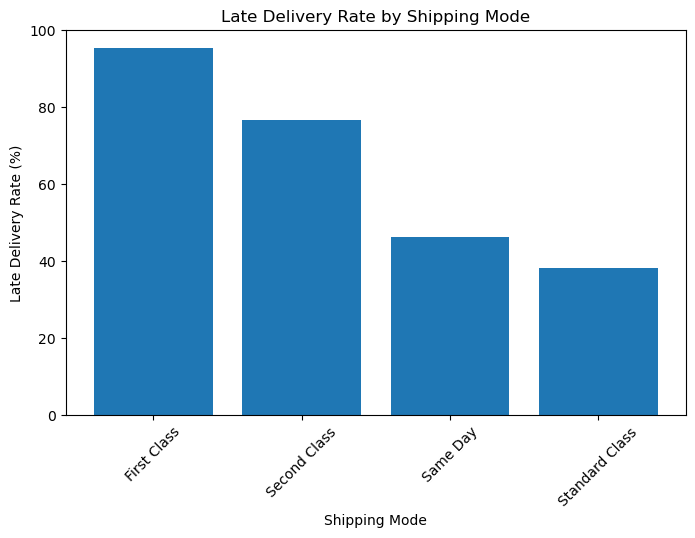

In [31]:
plt.figure(figsize=(8,5))

plt.bar(
    shipping_mode_analysis["shipping_mode"],
    shipping_mode_analysis["late_delivery_rate"]
)

plt.title("Late Delivery Rate by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Late Delivery Rate (%)")
plt.xticks(rotation=45)
plt.show()

## Data Cleaning and Cleaned Dataset Creation

In [32]:
# Insight 1: Late Delivery Rate by Shipping Mode
#
# The analysis shows that delivery performance is different for each shipping mode.
#
# First Class has the highest late delivery rate at 95.27%, which means almost all
# First Class orders were delivered late.
#
# Second Class also has a high late delivery rate at 76.72%. This means more than
# three out of every four Second Class orders were late.
#
# Same Day shipping has a lower late delivery rate at 46.15%, while Standard Class
# has the lowest late delivery rate at 38.13%.
#
# This result is important because First Class and Second Class are usually expected
# to be faster shipping options. However, in this dataset, these premium shipping
# methods are performing worse than Standard Class.
#
# Business Interpretation:
# The company may be overpromising delivery speed for First Class and Second Class
# orders. Customers who choose faster shipping usually expect quicker delivery, so
# late deliveries in these shipping modes can create customer dissatisfaction.
#
# Recommendation:
# The company should review First Class and Second Class shipping operations. It
# should check carrier performance, delivery promises, warehouse processing time,
# and regional shipping issues. Improving these shipping modes should be a priority
# because they have the highest late delivery rates.

In [33]:
df_final = df_clean.copy()

In [34]:
df_final.isnull().sum()

order_id                   0
order_date                 0
shipping_date              0
actual_shipping_days       0
scheduled_shipping_days    0
late_delivery_risk         0
delivery_status            0
shipping_mode              0
order_region               0
order_country              0
market                     0
category_name              0
product_name               0
sales                      0
profit                     0
quantity                   0
customer_segment           0
order_status               0
delay_days                 0
delivery_result            0
dtype: int64

In [35]:
df_final.duplicated().sum()

np.int64(8)

In [36]:
df_final = df_final.drop_duplicates()

In [37]:
df_final["order_date"] = pd.to_datetime(df_final["order_date"], errors="coerce")
df_final["shipping_date"] = pd.to_datetime(df_final["shipping_date"], errors="coerce")

In [38]:
df_final["order_year"] = df_final["order_date"].dt.year
df_final["order_month"] = df_final["order_date"].dt.month
df_final["order_month_name"] = df_final["order_date"].dt.month_name()

In [39]:
df_final["profit_margin"] = df_final["profit"] / df_final["sales"]

In [40]:
df_final["profit_margin"] = df_final["profit_margin"].replace([np.inf, -np.inf], np.nan)
df_final["profit_margin"] = df_final["profit_margin"].fillna(0)

In [41]:
df_final["delay_status"] = np.where(
    df_final["delay_days"] > 0,
    "Delayed",
    np.where(df_final["delay_days"] == 0, "On Time", "Early")
)

In [42]:
df_final.head()

,order_id,order_date,shipping_date,actual_shipping_days,scheduled_shipping_days,late_delivery_risk,delivery_status,shipping_mode,order_region,order_country,...,quantity,customer_segment,order_status,delay_days,delivery_result,order_year,order_month,order_month_name,profit_margin,delay_status
0,77202,2018-01-31 22:56:00,2018-02-03 22:56:00,3,4,0,Advance shipping,Standard Class,Southeast Asia,Indonesia,...,1,Consumer,COMPLETE,-1,On Time,2018,1,January,0.278413,Early
1,75939,2018-01-13 12:27:00,2018-01-18 12:27:00,5,4,1,Late delivery,Standard Class,South Asia,India,...,1,Consumer,PENDING,1,Late,2018,1,January,-0.760000,Delayed
2,75938,2018-01-13 12:06:00,2018-01-17 12:06:00,4,4,0,Shipping on time,Standard Class,South Asia,India,...,1,Consumer,CLOSED,0,On Time,2018,1,January,-0.756003,On Time
3,75937,2018-01-13 11:45:00,2018-01-16 11:45:00,3,4,0,Advance shipping,Standard Class,Oceania,Australia,...,1,Home Office,COMPLETE,-1,On Time,2018,1,January,0.069748,Early
4,75936,2018-01-13 11:24:00,2018-01-15 11:24:00,2,4,0,Advance shipping,Standard Class,Oceania,Australia,...,1,Corporate,PENDING_PAYMENT,-2,On Time,2018,1,January,0.409489,Early


In [43]:
df_final.shape

(180511, 25)

## Data Quality Check

In [44]:
df_final.to_csv(
    r"E:\data Analystic\Supply_Chain_Project\data\cleaned\supply_chain_cleaned.csv",
    index=False
)

In [45]:
data_quality_summary = {
    "Rows": df_final.shape[0],
    "Columns": df_final.shape[1],
    "Duplicate Rows": df_final.duplicated().sum(),
    "Missing Values": df_final.isnull().sum().sum(),
    "Unique Orders": df_final["order_id"].nunique(),
    "Date Range Start": df_final["order_date"].min(),
    "Date Range End": df_final["order_date"].max()
}

data_quality_summary

{'Rows': 180511,
 'Columns': 25,
 'Duplicate Rows': np.int64(0),
 'Missing Values': np.int64(0),
 'Unique Orders': 65752,
 'Date Range Start': Timestamp('2015-01-01 00:00:00'),
 'Date Range End': Timestamp('2018-01-31 23:38:00')}

## Late Delivery Rate by Region

In [46]:
## Data Quality Check

#After cleaning the dataset, I performed a data quality check to make sure the data was ready for analysis.

#The cleaned dataset contains 180,511 rows and 25 columns. The dataset has 0 duplicate rows and 0 missing values, which means the cleaned data is reliable for analysis.

#The dataset includes 65,752 unique orders. This is important because one order can appear in multiple rows if the order contains multiple products.

#The order date range is from January 1, 2015 to January 31, 2018. This gives enough historical data to analyze delivery delays, shipping performance, sales, and profit trends.

#This data quality check confirms that the cleaned dataset is ready for business analysis, SQL analysis, and Tableau dashboard creation.

In [47]:
region_analysis = df_final.groupby("order_region").agg(
    total_orders=("order_id", "nunique"),
    total_sales=("sales", "sum"),
    total_profit=("profit", "sum"),
    avg_delay_days=("delay_days", "mean")
).reset_index()

region_analysis.head()

,order_region,total_orders,total_sales,total_profit,avg_delay_days
0,Canada,309,1.868610e+05,23900.709960,0.391032
1,Caribbean,2806,1.650779e+06,171825.640024,0.546471
2,Central Africa,556,3.272630e+05,33447.269960,0.639833
3,Central America,9396,5.664982e+06,616290.090651,0.561931
4,Central Asia,184,1.098399e+05,13045.280051,0.645570


In [48]:
late_orders_by_region = df_final[df_final["late_delivery_risk"] == 1].groupby("order_region")["order_id"].nunique().reset_index()

late_orders_by_region = late_orders_by_region.rename(columns={
    "order_id": "late_orders"
})

late_orders_by_region.head()

,order_region,late_orders
0,Canada,153
1,Caribbean,1487
2,Central Africa,320
3,Central America,5156
4,Central Asia,102


In [49]:
region_analysis = region_analysis.merge(
    late_orders_by_region,
    on="order_region",
    how="left"
)

region_analysis.head()

,order_region,total_orders,total_sales,total_profit,avg_delay_days,late_orders
0,Canada,309,1.868610e+05,23900.709960,0.391032,153
1,Caribbean,2806,1.650779e+06,171825.640024,0.546471,1487
2,Central Africa,556,3.272630e+05,33447.269960,0.639833,320
3,Central America,9396,5.664982e+06,616290.090651,0.561931,5156
4,Central Asia,184,1.098399e+05,13045.280051,0.645570,102


In [50]:
region_analysis["late_delivery_rate"] = (
    region_analysis["late_orders"] / region_analysis["total_orders"]
) * 100

In [51]:
region_analysis = region_analysis.sort_values(
    by="late_delivery_rate",
    ascending=False
)

region_analysis["late_delivery_rate"] = region_analysis["late_delivery_rate"].round(2)
region_analysis["avg_delay_days"] = region_analysis["avg_delay_days"].round(2)
region_analysis["total_sales"] = region_analysis["total_sales"].round(2)
region_analysis["total_profit"] = region_analysis["total_profit"].round(2)

region_analysis

,order_region,total_orders,total_sales,total_profit,avg_delay_days,late_orders,late_delivery_rate
2,Central Africa,556,327263.02,33447.27,0.64,320,57.55
5,East Africa,613,376234.90,43167.73,0.57,348,56.77
14,South of USA,1345,785783.95,88114.88,0.58,753,55.99
20,West Asia,2022,1174671.78,118815.41,0.57,1132,55.98
8,Eastern Europe,1292,774266.57,79717.05,0.58,723,55.96
13,South Asia,3335,1553560.95,165695.24,0.60,1865,55.92
22,Western Europe,10010,5894080.82,625423.12,0.60,5585,55.79
15,Southeast Asia,4356,1932495.57,211342.82,0.56,2421,55.58
4,Central Asia,184,109839.93,13045.28,0.65,102,55.43
18,US Center,1935,1151155.78,131022.23,0.59,1071,55.35


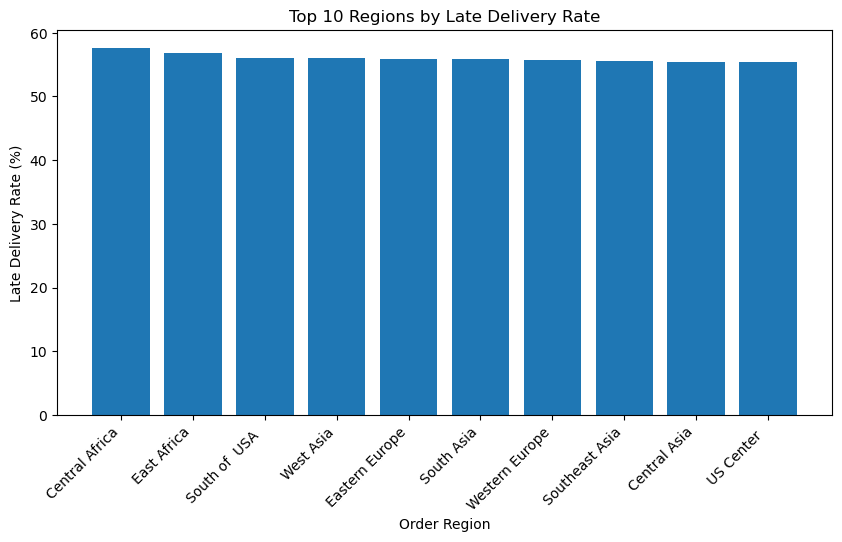

In [52]:
top_10_regions = region_analysis.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top_10_regions["order_region"],
    top_10_regions["late_delivery_rate"]
)

plt.title("Top 10 Regions by Late Delivery Rate")
plt.xlabel("Order Region")
plt.ylabel("Late Delivery Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.show()

## Profit Impact of Late Deliverie

In [53]:
## Insight 2: Late Delivery Rate by Region
#The region analysis shows that delivery delays vary by location. Central Africa had the highest late delivery rate at 57.55%, followed by East Africa at 56.77%.
#Several other regions, including South of USA, West Asia, Eastern Europe, South Asia, and Western Europe, also had late delivery rates above 55%.
#This means delivery delays are not only caused by shipping mode. Location also plays an important role in supply chain performance.

### Business Interpretation
#Regions with higher late delivery rates may have transportation challenges, warehouse delays, carrier issues, customs problems, or longer delivery distances. These regional problems can reduce customer satisfaction and increase operational risk.

### Recommendation
#The company should review delivery operations in the highest-risk regions first, especially Central Africa and East Africa. It should compare carrier performance, warehouse locations, delivery routes, and regional shipping promises. Improving performance in these regions can help reduce the overall late delivery rate.

In [54]:
profit_delivery_analysis = df_final.groupby("delivery_result").agg(
    total_orders=("order_id", "nunique"),
    total_sales=("sales", "sum"),
    total_profit=("profit", "sum"),
    avg_profit=("profit", "mean"),
    avg_delay_days=("delay_days", "mean")
).reset_index()

profit_delivery_analysis

,delivery_result,total_orders,total_sales,total_profit,avg_profit,avg_delay_days
0,Late,36048,2.012564e+07,2.140043e+06,21.622275,1.618203
1,On Time,29704,1.665739e+07,1.826687e+06,22.403165,-0.711640


In [55]:
profit_delivery_analysis["total_sales"] = profit_delivery_analysis["total_sales"].round(2)
profit_delivery_analysis["total_profit"] = profit_delivery_analysis["total_profit"].round(2)
profit_delivery_analysis["avg_profit"] = profit_delivery_analysis["avg_profit"].round(2)
profit_delivery_analysis["avg_delay_days"] = profit_delivery_analysis["avg_delay_days"].round(2)

profit_delivery_analysis

,delivery_result,total_orders,total_sales,total_profit,avg_profit,avg_delay_days
0,Late,36048,20125635.36,2140043.02,21.62,1.62
1,On Time,29704,16657389.85,1826686.85,22.40,-0.71


In [56]:
profit_delivery_analysis["profit_margin"] = (
    profit_delivery_analysis["total_profit"] / profit_delivery_analysis["total_sales"]
) * 100

profit_delivery_analysis["profit_margin"] = profit_delivery_analysis["profit_margin"].round(2)

profit_delivery_analysis

,delivery_result,total_orders,total_sales,total_profit,avg_profit,avg_delay_days,profit_margin
0,Late,36048,20125635.36,2140043.02,21.62,1.62,10.63
1,On Time,29704,16657389.85,1826686.85,22.40,-0.71,10.97


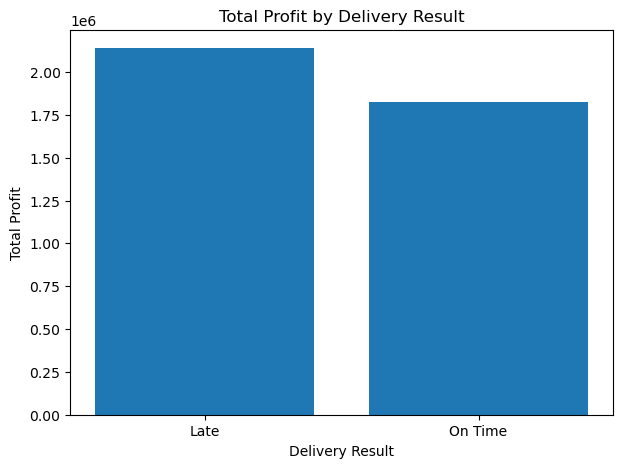

In [57]:
plt.figure(figsize=(7,5))

plt.bar(
    profit_delivery_analysis["delivery_result"],
    profit_delivery_analysis["total_profit"]
)

plt.title("Total Profit by Delivery Result")
plt.xlabel("Delivery Result")
plt.ylabel("Total Profit")
plt.show()

In [58]:
profit_delivery_analysis

,delivery_result,total_orders,total_sales,total_profit,avg_profit,avg_delay_days,profit_margin
0,Late,36048,20125635.36,2140043.02,21.62,1.62,10.63
1,On Time,29704,16657389.85,1826686.85,22.40,-0.71,10.97


## Late Delivery Rate by Product Category

In [59]:
## Insight 3: Profit Impact of Late Deliveries

#The profit analysis compares late orders and on-time orders to understand whether delivery delays affect profitability.
#Late orders generated $2.14 million in total profit, while on-time orders generated $1.83 million in total profit. However, this does not mean late orders are better. Late orders had higher total profit mainly because there were more late orders in the dataset.
#A better comparison is average profit and profit margin. Late orders had an average profit of $21.62, while on-time orders had a slightly higher average profit of $22.40.
#The profit margin for late orders was 10.63%, compared to 10.97% for on-time orders. This shows that on-time orders were slightly more profitable than late orders.

### Business Interpretation
#Late deliveries do not only affect customer satisfaction. They may also slightly reduce profitability and operational efficiency. Even though late orders created more total profit because of higher order volume, on-time orders performed better when comparing average profit and profit margin.

### Recommendation
#The company should focus on reducing late deliveries, especially in high-volume shipping modes and regions. Improving delivery performance can help protect customer satisfaction while also supporting better profit margins.

In [60]:
category_analysis = df_final.groupby("category_name").agg(
    total_orders=("order_id", "nunique"),
    total_sales=("sales", "sum"),
    total_profit=("profit", "sum"),
    avg_delay_days=("delay_days", "mean")
).reset_index()

category_analysis.head()

,category_name,total_orders,total_sales,total_profit,avg_delay_days
0,Accessories,1753,133671.508825,16643.520074,0.589326
1,As Seen on TV!,68,20597.939964,714.429980,0.661765
2,Baby,207,12229.560379,1525.029992,0.444444
3,Baseball & Softball,628,94057.152543,12762.130067,0.583861
4,Basketball,64,27099.329343,1845.670003,0.477612


In [61]:
late_orders_by_category = df_final[df_final["late_delivery_risk"] == 1].groupby("category_name")["order_id"].nunique().reset_index()

late_orders_by_category = late_orders_by_category.rename(columns={
    "order_id": "late_orders"
})

late_orders_by_category.head()

,category_name,late_orders
0,Accessories,999
1,As Seen on TV!,39
2,Baby,109
3,Baseball & Softball,347
4,Basketball,35


In [62]:
category_analysis = category_analysis.merge(
    late_orders_by_category,
    on="category_name",
    how="left"
)

category_analysis.head()

,category_name,total_orders,total_sales,total_profit,avg_delay_days,late_orders
0,Accessories,1753,133671.508825,16643.520074,0.589326,999
1,As Seen on TV!,68,20597.939964,714.429980,0.661765,39
2,Baby,207,12229.560379,1525.029992,0.444444,109
3,Baseball & Softball,628,94057.152543,12762.130067,0.583861,347
4,Basketball,64,27099.329343,1845.670003,0.477612,35


In [63]:
category_analysis["late_delivery_rate"] = (
    category_analysis["late_orders"] / category_analysis["total_orders"]
) * 100

In [64]:
category_analysis = category_analysis.sort_values(
    by="late_delivery_rate",
    ascending=False
)

category_analysis["late_delivery_rate"] = category_analysis["late_delivery_rate"].round(2)
category_analysis["avg_delay_days"] = category_analysis["avg_delay_days"].round(2)
category_analysis["total_sales"] = category_analysis["total_sales"].round(2)
category_analysis["total_profit"] = category_analysis["total_profit"].round(2)

category_analysis.head(10)

,category_name,total_orders,total_sales,total_profit,avg_delay_days,late_orders,late_delivery_rate
23,Golf Bags & Carts,61,10369.39,1810.07,0.77,42,68.85
32,Lacrosse,341,39464.79,4364.29,0.66,205,60.12
37,Pet Supplies,492,41524.80,3589.26,0.71,290,58.94
8,Cameras,592,267607.69,30289.80,0.65,344,58.11
41,Strength Training,111,54895.53,332.31,0.67,64,57.66
1,As Seen on TV!,68,20597.94,714.43,0.66,39,57.35
36,Music,434,113122.10,14436.32,0.57,248,57.14
0,Accessories,1753,133671.51,16643.52,0.59,999,56.99
19,Fitness Accessories,307,35601.44,5258.39,0.61,174,56.68
5,Books,405,12587.40,883.01,0.53,229,56.54


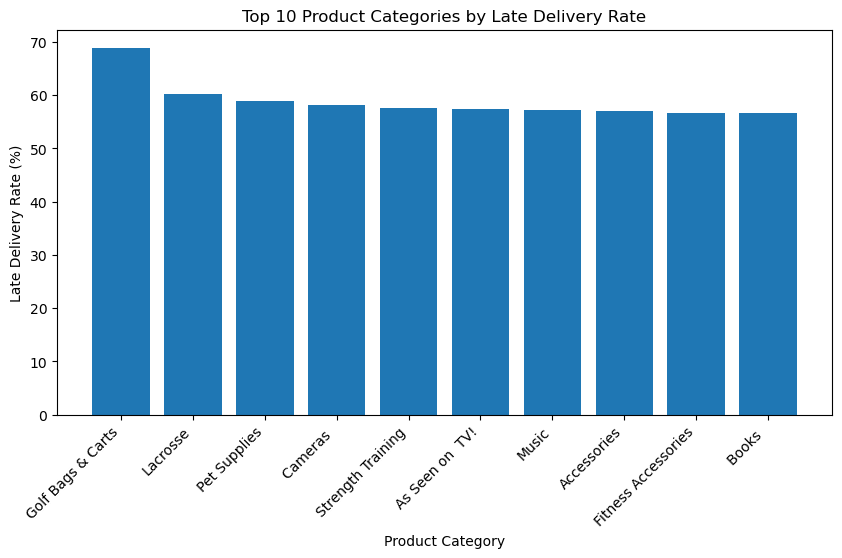

In [65]:
top_10_categories = category_analysis.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top_10_categories["category_name"],
    top_10_categories["late_delivery_rate"]
)

plt.title("Top 10 Product Categories by Late Delivery Rate")
plt.xlabel("Product Category")
plt.ylabel("Late Delivery Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.show()

In [66]:
high_volume_category_analysis = category_analysis[category_analysis["total_orders"] >= 500]

high_volume_category_analysis = high_volume_category_analysis.sort_values(
    by="late_delivery_rate",
    ascending=False
)

high_volume_category_analysis.head(10)

,category_name,total_orders,total_sales,total_profit,avg_delay_days,late_orders,late_delivery_rate
8,Cameras,592,267607.69,30289.80,0.65,344,58.11
0,Accessories,1753,133671.51,16643.52,0.59,999,56.99
48,Women's Clothing,650,140283.00,19102.85,0.65,367,56.46
25,Golf Gloves,1064,116695.39,12975.49,0.62,598,56.20
17,Electronics,3061,371034.64,40891.38,0.57,1711,55.90
26,Golf Shoes,523,107998.00,12406.07,0.58,291,55.64
44,Trade-In,964,68721.78,7915.37,0.63,534,55.39
21,Girls' Apparel,1191,151706.20,17288.57,0.59,659,55.33
3,Baseball & Softball,628,94057.15,12762.13,0.58,347,55.25
12,Cleats,20386,4431282.89,494595.96,0.58,11228,55.08


In [67]:
## Insight 4: Late Delivery Rate by Product Category
#The category analysis shows that delivery delays vary across product categories. Golf Bags & Carts had the highest late delivery rate at 68.85%, followed by Lacrosse at 60.12% and Pet Supplies at 58.94%.
#This means some product categories are more likely to experience delivery delays than others.
#However, it is important to consider order volume. For example, Golf Bags & Carts had a very high late delivery rate, but it had only 61 total orders. A category with a smaller number of orders can show a high percentage more easily.

## Business Interpretation
#The company should not only look at late delivery percentage. It should also consider total order volume, sales, and profit. Categories with both high late delivery rates and high order volume are more important because they affect more customers.

## Recommendation
#The company should review product categories with high delay rates and enough order volume. These categories may have inventory issues, warehouse handling problems, supplier delays, or shipping challenges. Focusing on high-volume delayed categories can help improve customer experience and reduce operational problems.

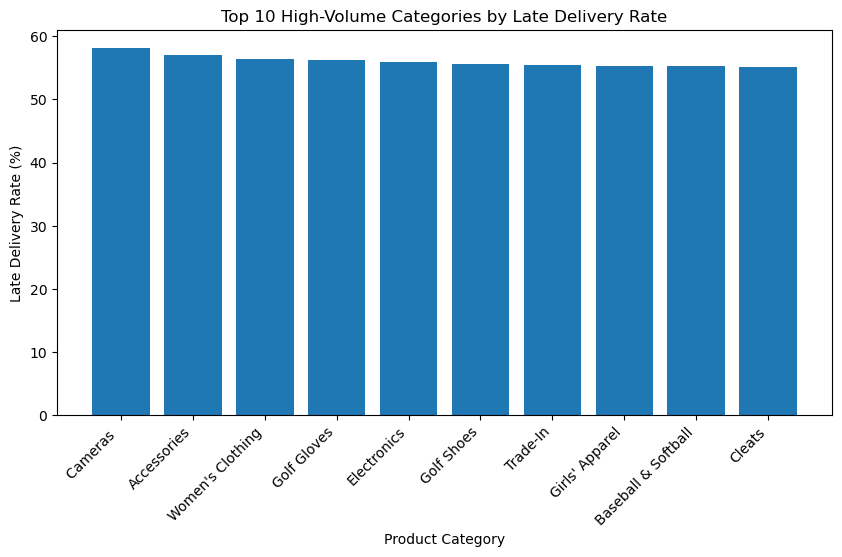

In [68]:
top_10_high_volume_categories = high_volume_category_analysis.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top_10_high_volume_categories["category_name"],
    top_10_high_volume_categories["late_delivery_rate"]
)

plt.title("Top 10 High-Volume Categories by Late Delivery Rate")
plt.xlabel("Product Category")
plt.ylabel("Late Delivery Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.show()

## Monthly Late Delivery Trend Analysis

In [69]:
shipping_region_analysis = df_final.groupby(["shipping_mode", "order_region"]).agg(
    total_orders=("order_id", "nunique"),
    total_sales=("sales", "sum"),
    total_profit=("profit", "sum"),
    avg_delay_days=("delay_days", "mean")
).reset_index()

shipping_region_analysis.head()

,shipping_mode,order_region,total_orders,total_sales,total_profit,avg_delay_days
0,First Class,Canada,58,33802.740681,2906.979997,1.0
1,First Class,Caribbean,415,234070.244567,29981.189964,1.0
2,First Class,Central Africa,96,57285.761153,6220.279981,1.0
3,First Class,Central America,1448,883448.856737,97290.150079,1.0
4,First Class,Central Asia,19,11901.370216,997.760045,1.0


In [70]:
late_orders_shipping_region = df_final[df_final["late_delivery_risk"] == 1].groupby(
    ["shipping_mode", "order_region"]
)["order_id"].nunique().reset_index()

late_orders_shipping_region = late_orders_shipping_region.rename(columns={
    "order_id": "late_orders"
})

late_orders_shipping_region.head()

,shipping_mode,order_region,late_orders
0,First Class,Canada,53
1,First Class,Caribbean,392
2,First Class,Central Africa,89
3,First Class,Central America,1382
4,First Class,Central Asia,19


In [71]:
shipping_region_analysis = shipping_region_analysis.merge(
    late_orders_shipping_region,
    on=["shipping_mode", "order_region"],
    how="left"
)

shipping_region_analysis.head()

,shipping_mode,order_region,total_orders,total_sales,total_profit,avg_delay_days,late_orders
0,First Class,Canada,58,33802.740681,2906.979997,1.0,53
1,First Class,Caribbean,415,234070.244567,29981.189964,1.0,392
2,First Class,Central Africa,96,57285.761153,6220.279981,1.0,89
3,First Class,Central America,1448,883448.856737,97290.150079,1.0,1382
4,First Class,Central Asia,19,11901.370216,997.760045,1.0,19


In [72]:
shipping_region_analysis["late_orders"] = shipping_region_analysis["late_orders"].fillna(0)

In [73]:
shipping_region_analysis["late_delivery_rate"] = (
    shipping_region_analysis["late_orders"] / shipping_region_analysis["total_orders"]
) * 100

In [74]:
shipping_region_risk = shipping_region_analysis[
    shipping_region_analysis["total_orders"] >= 100
]

In [75]:
shipping_region_risk = shipping_region_risk.sort_values(
    by="late_delivery_rate",
    ascending=False
)

shipping_region_risk["late_delivery_rate"] = shipping_region_risk["late_delivery_rate"].round(2)
shipping_region_risk["avg_delay_days"] = shipping_region_risk["avg_delay_days"].round(2)
shipping_region_risk["total_sales"] = shipping_region_risk["total_sales"].round(2)
shipping_region_risk["total_profit"] = shipping_region_risk["total_profit"].round(2)

shipping_region_risk.head(15)

,shipping_mode,order_region,total_orders,total_sales,total_profit,avg_delay_days,late_orders,late_delivery_rate
9,First Class,North Africa,155,96183.32,13672.02,1.0,150,96.77
17,First Class,Southern Europe,525,332145.32,38535.67,1.0,507,96.57
13,First Class,South Asia,543,260593.54,23808.11,1.0,523,96.32
20,First Class,West Asia,329,195131.57,21383.48,1.0,316,96.05
19,First Class,West Africa,145,89661.69,9916.11,1.0,139,95.86
10,First Class,Northern Europe,551,308814.85,28384.50,1.0,528,95.83
6,First Class,East of USA,357,211524.19,21560.31,1.0,342,95.80
18,First Class,US Center,328,191715.86,24436.02,1.0,314,95.73
3,First Class,Central America,1448,883448.86,97290.15,1.0,1382,95.44
22,First Class,Western Europe,1590,936797.50,115193.42,1.0,1516,95.35


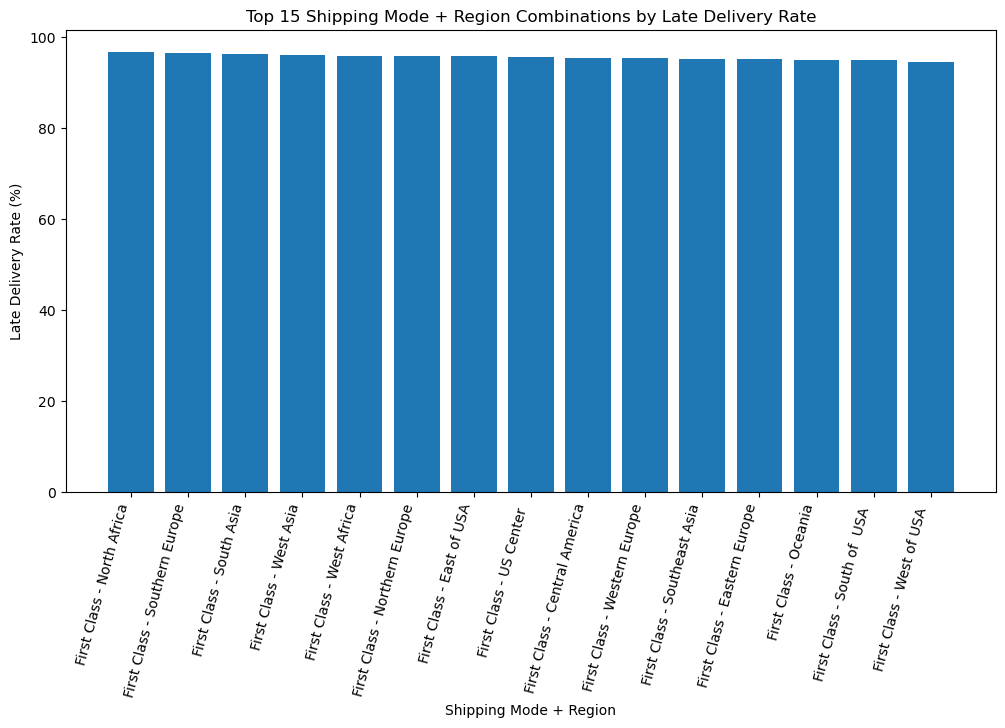

In [76]:
top_15_shipping_region = shipping_region_risk.head(15).copy()

top_15_shipping_region["shipping_region"] = (
    top_15_shipping_region["shipping_mode"] + " - " + top_15_shipping_region["order_region"]
)

plt.figure(figsize=(12,6))

plt.bar(
    top_15_shipping_region["shipping_region"],
    top_15_shipping_region["late_delivery_rate"]
)

plt.title("Top 15 Shipping Mode + Region Combinations by Late Delivery Rate")
plt.xlabel("Shipping Mode + Region")
plt.ylabel("Late Delivery Rate (%)")
plt.xticks(rotation=75, ha="right")
plt.show()

In [77]:
## Insight 5: Shipping Mode and Region Risk Analysis
#To better understand the delivery delay problem, I analyzed late delivery rate by combining shipping mode and order region.
#The results show that First Class shipping has very high late delivery rates across multiple regions. For example, First Class orders in North Africa had a late delivery rate of 96.77%, followed by Southern Europe at 96.57%, South Asia at 96.32%, and West Asia at 96.05%.
#This is an important finding because First Class is usually expected to be a faster shipping option. However, the data shows that First Class orders are consistently late across many regions.

## Business Interpretation

#The delay problem is not limited to one location. Since First Class shipping appears repeatedly in the highest-risk combinations, the company may have a broader issue with First Class delivery promises, carrier performance, warehouse processing, or fulfillment planning.

## Recommendation
#The company should investigate First Class shipping operations across regions. It should review whether delivery promises for First Class are realistic, compare carrier performance by region, and identify whether fulfillment centers are causing delays before shipment. Improving First Class performance should be a high priority because customers choosing premium shipping expect faster delivery.

## Monthly Trend Analysis

In [78]:
monthly_analysis = df_final.groupby(["order_year", "order_month"]).agg(
    total_orders=("order_id", "nunique"),
    total_sales=("sales", "sum"),
    total_profit=("profit", "sum"),
    avg_delay_days=("delay_days", "mean")
).reset_index()

monthly_analysis.head()

,order_year,order_month,total_orders,total_sales,total_profit,avg_delay_days
0,2015,1,1787,1.051590e+06,111660.740132,0.540210
1,2015,2,1585,9.266099e+05,99140.660196,0.598350
2,2015,3,1781,1.051054e+06,113778.210191,0.572281
3,2015,4,1710,1.014223e+06,108083.679957,0.547317
4,2015,5,1776,1.050478e+06,112147.900143,0.556655


In [79]:
late_orders_by_month = df_final[df_final["late_delivery_risk"] == 1].groupby(
    ["order_year", "order_month"]
)["order_id"].nunique().reset_index()

late_orders_by_month = late_orders_by_month.rename(columns={
    "order_id": "late_orders"
})

late_orders_by_month.head()

,order_year,order_month,late_orders
0,2015,1,963
1,2015,2,871
2,2015,3,978
3,2015,4,927
4,2015,5,969


In [80]:
monthly_analysis = monthly_analysis.merge(
    late_orders_by_month,
    on=["order_year", "order_month"],
    how="left"
)

monthly_analysis.head()

,order_year,order_month,total_orders,total_sales,total_profit,avg_delay_days,late_orders
0,2015,1,1787,1.051590e+06,111660.740132,0.540210,963
1,2015,2,1585,9.266099e+05,99140.660196,0.598350,871
2,2015,3,1781,1.051054e+06,113778.210191,0.572281,978
3,2015,4,1710,1.014223e+06,108083.679957,0.547317,927
4,2015,5,1776,1.050478e+06,112147.900143,0.556655,969


In [81]:
monthly_analysis["late_delivery_rate"] = (
    monthly_analysis["late_orders"] / monthly_analysis["total_orders"]
) * 100

In [82]:
monthly_analysis["month_date"] = pd.to_datetime(
    monthly_analysis["order_year"].astype(str) + "-" + monthly_analysis["order_month"].astype(str) + "-01"
)

In [83]:
monthly_analysis["late_delivery_rate"] = monthly_analysis["late_delivery_rate"].round(2)
monthly_analysis["avg_delay_days"] = monthly_analysis["avg_delay_days"].round(2)
monthly_analysis["total_sales"] = monthly_analysis["total_sales"].round(2)
monthly_analysis["total_profit"] = monthly_analysis["total_profit"].round(2)

monthly_analysis.head()

,order_year,order_month,total_orders,total_sales,total_profit,avg_delay_days,late_orders,late_delivery_rate,month_date
0,2015,1,1787,1051590.08,111660.74,0.54,963,53.89,2015-01-01
1,2015,2,1585,926609.92,99140.66,0.60,871,54.95,2015-02-01
2,2015,3,1781,1051053.70,113778.21,0.57,978,54.91,2015-03-01
3,2015,4,1710,1014223.32,108083.68,0.55,927,54.21,2015-04-01
4,2015,5,1776,1050478.44,112147.90,0.56,969,54.56,2015-05-01


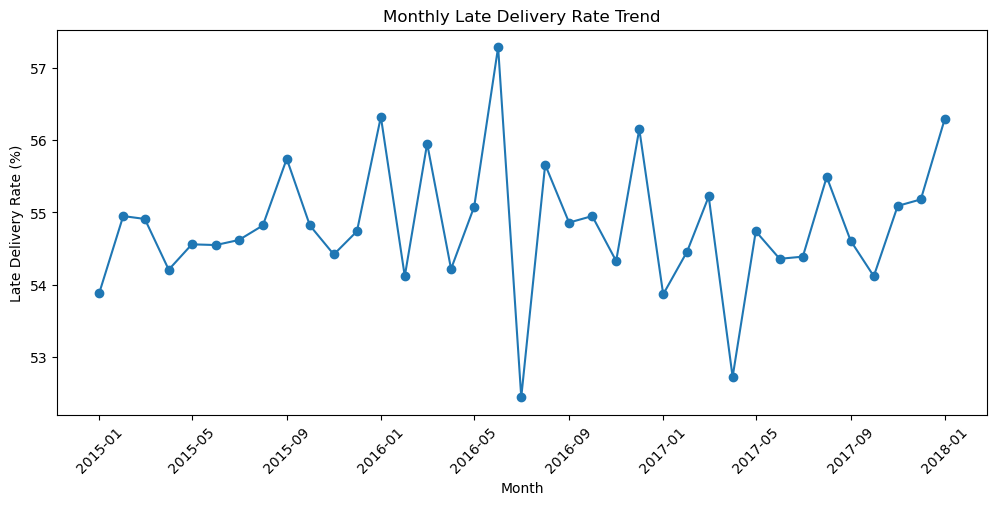

In [84]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_analysis["month_date"],
    monthly_analysis["late_delivery_rate"],
    marker="o"
)

plt.title("Monthly Late Delivery Rate Trend")
plt.xlabel("Month")
plt.ylabel("Late Delivery Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [86]:
## Insight 6: Monthly Late Delivery Trend
#The monthly trend analysis shows how the late delivery rate changed over time.
#This analysis is important because it helps identify whether delivery performance improved, declined, or stayed consistent during the business period.
#By tracking late delivery rate month by month, the company can monitor supply chain performance and quickly identify months where delivery problems increased.

## Business Interpretation
#If the late delivery rate stays high across many months, it means the company has a continuous supply chain performance issue rather than a one-time problem.
#If some months show higher delay rates, the company should investigate possible causes such as seasonal demand, warehouse capacity, carrier delays, or regional shipping problems.

## Recommendation
#The company should monitor late delivery rate every month as a key performance indicator. Monthly tracking can help managers identify delay problems early and take action before they affect more customers.

## Export Final Analysis Tables for Tableau Dashboard

In [87]:
shipping_mode_analysis.to_csv(
    r"E:\data Analystic\Supply_Chain_Project\data\cleaned\shipping_mode_analysis.csv",
    index=False
)

In [88]:
region_analysis.to_csv(
    r"E:\data Analystic\Supply_Chain_Project\data\cleaned\region_analysis.csv",
    index=False
)

In [89]:
profit_delivery_analysis.to_csv(
    r"E:\data Analystic\Supply_Chain_Project\data\cleaned\profit_delivery_analysis.csv",
    index=False
)

In [90]:
high_volume_category_analysis.to_csv(
    r"E:\data Analystic\Supply_Chain_Project\data\cleaned\high_volume_category_analysis.csv",
    index=False
)

In [91]:
shipping_region_risk.to_csv(
    r"E:\data Analystic\Supply_Chain_Project\data\cleaned\shipping_region_risk.csv",
    index=False
)

In [92]:
monthly_analysis.to_csv(
    r"E:\data Analystic\Supply_Chain_Project\data\cleaned\monthly_analysis.csv",
    index=False
)

In [93]:
import os

cleaned_folder = r"E:\data Analystic\Supply_Chain_Project\data\cleaned"

os.listdir(cleaned_folder)

['high_volume_category_analysis.csv',
 'monthly_analysis.csv',
 'profit_delivery_analysis.csv',
 'region_analysis.csv',
 'shipping_mode_analysis.csv',
 'shipping_region_risk.csv',
 'supply_chain_cleaned.csv']

In [94]:
## Analysis 7 Summary: Exported Final Analysis Tables
#In this step, I exported the final cleaned dataset and analysis summary tables as CSV files.
#These exported files will be used for Tableau dashboard building and future SQL analysis.

##The exported files include:
# `supply_chain_cleaned.csv`: main cleaned dataset
# `shipping_mode_analysis.csv`: late delivery performance by shipping mode
# `region_analysis.csv`: late delivery performance by region
# `profit_delivery_analysis.csv`: profit comparison between late and on-time orders
# `high_volume_category_analysis.csv`: high-volume product categories with late delivery risk
# `shipping_region_risk.csv`: risky shipping mode and region combinations
# `monthly_analysis.csv`: monthly late delivery trend

## Business Purpose
#Exporting these files makes the project more organized and professional. Instead of using only one large raw dataset, the project now has separate analysis-ready tables for dashboard creation.
#This also makes the Tableau process easier because each CSV file already answers a specific business question.

## Next Step
#The next step is to use these cleaned and exported CSV files to build a Tableau dashboard that shows delivery delays, profit impact, regional risk, shipping mode performance, and monthly trends.